<a href="https://colab.research.google.com/github/MelB18/EasyQuanten/blob/main/ErsteSchritte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inhaltsverzeichnis

1.   [Vorbereitung](#vorbereitung)
2.   [Qubits](#qubits)
3.   [Gates](#gates)
4.   [Observable](#observable)



<a id="vorbereitung"></a>
# Vorbereitung

Als Erstes müssen wir verschiedene Python Bibliotheken installieren und importieren.


In [ ]:
# Install required packages.

%pip install --upgrade 'qiskit[visualization]>=2.5.0' qiskit-aer qiskit-ibm-runtime matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 107.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.2/234.2 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/

In [ ]:
import os
import platform
import shutil
import subprocess
import sys

import qiskit

from qiskit.circuit import QuantumCircuit
from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator, Pauli, DensityMatrix
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import array_to_latex, plot_histogram, plot_state_qsphere, plot_bloch_multivector
from qiskit_aer import AerSimulator
#from qiskit_ibm_runtime import Batch, QiskitRuntimeService
#from qiskit_ibm_runtime import EstimatorV2 as Estimator
#from qiskit_ibm_runtime import SamplerV2 as Sampler

import matplotlib.pyplot as plt
import numpy as np

from numpy import sqrt

print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.5.2


<a id="qubits"></a>
# Qubits

In diesem Kapitel werden die wichtigsten Grundlagen erklärt.

## Bits versus Qubits

Bits können den Wert 0 oder 1 haben, ähnlich wie Münzen Kopf oder Zahl sein können.

Wenn Münzen flach auf dem Tisch liegen, ist die Wahrscheinlich für Kopf oder Zahl jeweils 100% oder 0%.

Wirft man die Münze in die Luft, ist die Wahrscheinlichkeit - solange sie in der Luft ist - irgendwas dazwischen.

Zum Beispiel: 30% Kopf und 70% Zahl

Ein entsprechender Wahrscheinlichkeitsvektor kann wie folgt definiert werden:

$$
\begin{pmatrix}
0.3
\\
0.7
\end{pmatrix}
$$

In [ ]:
bitVec = np.array([[0.3],[0.7]])

print("Wahrscheinlichkeitsvektor (30% Kopf und 70% Zahl): ")
print(bitVec)
display(array_to_latex(bitVec))

Wahrscheinlichkeitsvektor (30% Kopf und 70% Zahl): 
[[0.3]
 [0.7]]


<IPython.core.display.Latex object>

Für einen Wahrscheinlichkeitsvektor muss festgelegt werden, welcher Wert oben/als erstes und welcher Wert unten/als zweites steht.

In unserem Beispiel kommt zuerst die Wahrscheinlichkeit  für Kopf und danach die Wahrscheinlichkeit für Zahl.

Wichtig: Damit es ein gültiger Wahrscheinlichkeitsvektor ist, muss der Vektor aus reelen Zahlen zwischen 0 und 1 bestehen, die in Summe 1 ergeben.

In [ ]:
print("Wahrscheinlichkeit Kopf: ",bitVec[0])
print("Wahrscheinlichkeit Zahl: ",bitVec[1])
print("Summe: ",bitVec[0]+bitVec[1])


Wahrscheinlichkeit Kopf:  [0.3]
Wahrscheinlichkeit Zahl:  [0.7]
Summe:  [1.]


Für Wahrscheinlichkeitsvektoren von Bits ist die allgemeine Festlegung, dass oben die Wahrscheinlichkeit von 0 und unten die Wahrscheinlichkeit von 1 steht.

Der Wahrscheinlichkeitsvektor für 100% Wert 0 sieht wie folgt aus:

$$
\begin{pmatrix}
1
\\
0
\end{pmatrix}
$$


In [ ]:
bitZero = np.array([[1],[0]])
bitOne = np.array([[0],[1]])

print("Wahrscheinlichkeitsvektor für 100% Wert 0 (und 0% Wert 1): ")
print(bitZero)
display(array_to_latex(bitZero))
print("\nWahrscheinlichkeitsvektor für 100% Wert 1 (und 0% Wert 0): ")
print(bitOne)
display(array_to_latex(bitOne))

Wahrscheinlichkeitsvektor für 100% Wert 0 (und 0% Wert 1): 
[[1]
 [0]]


<IPython.core.display.Latex object>


Wahrscheinlichkeitsvektor für 100% Wert 1 (und 0% Wert 0): 
[[0]
 [1]]


<IPython.core.display.Latex object>

## Zustandsvektoren von Qubits

Qubits lassen sich ähnlich wie Bits als Vektor mit zwei Zahlen schreiben.

Es gibt jedoch zwei Hauptunterschiede:


1.   Der Vektor kann imaginäre Zahlen enthalten und nicht nur reele Zahlen
2.   Um die Wahrscheinlichkeiten zu bestimmen, müssen die Zahlen quadriert werden.


Wie bei einem Wahrscheinlichkeitsvektor eines Bit, muss bei einen Qubit Zustandsvektor die Summe der beiden Wahrscheinlichkeiten 1 ergeben.


Vektor für 100% Zustand 0 (und 0% Wert 1):

$$
\begin{pmatrix}
1
\\
0
\end{pmatrix}
$$

In [ ]:
zero = Statevector([1,0])

print("Andere Schreibweise für diesen Vektor: ")
#display(zero.draw("text"))
display(zero.draw("latex"))

Andere Schreibweise für diesen Vektor: 


<IPython.core.display.Latex object>

Vektor für 100% Zustand 1 (und 0% Wert 0):


$$
\begin{pmatrix}
0
\\
1
\end{pmatrix}
$$

In [ ]:
one = Statevector([0,1])

print("Andere Schreibweise für diesen Vektor: ")
#display(one.draw("text"))
display(one.draw("latex"))


Andere Schreibweise für diesen Vektor: 


<IPython.core.display.Latex object>

Um zu prüfen, ob ein gültiger Qubit Zustandsvektor definiert wurde, müssen die zwei Zahlen quadriert und danach addiert werden. Das Ergebnis muss dann 1 ergeben.


Die Prüfung kann mit Hilfe der folgenden Funktion durchgeführt werden:

In [ ]:
display(zero.is_valid())
display(one.is_valid())

True

True

Die Bedeutung der Qubit Zustandsvektoren kann man mit Hilfe der Bloch Kugel visualisieren:

* 100% Zustand 0: Nordpol
* 100% Zustand 1: Südpol

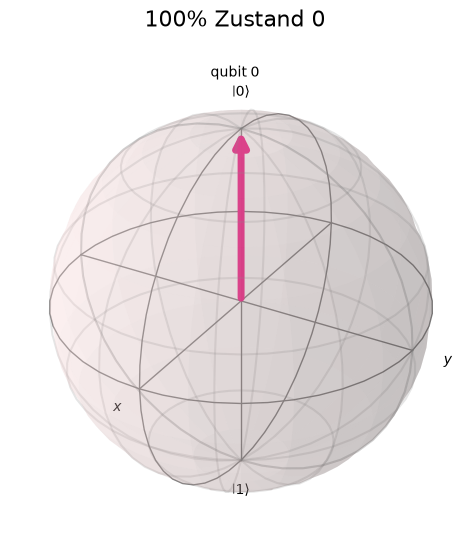

In [ ]:
plot_bloch_multivector(zero, "100% Zustand 0")

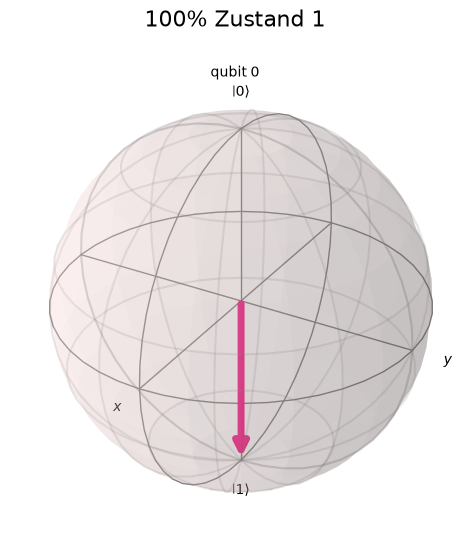

In [ ]:
plot_bloch_multivector(one, "100% Zustand 1")

## Berechnung des Bloch Vektors



Für einen Qubit-Zustand

$$
|\psi\rangle =
\begin{pmatrix}
\alpha\\
\beta
\end{pmatrix}
$$

gilt

$$
x = 2\operatorname{Re}(\alpha^*\beta),
\qquad
y = 2\operatorname{Im}(\alpha^*\beta),
\qquad
z = |\alpha|^2 - |\beta|^2.
$$





Berechnung des Bloch Vektors für den Qubit Zustandsvektor

$$
|\psi\rangle =
\begin{pmatrix}
\frac{3}{5}\\
\frac{4}{5}
\end{pmatrix}
=
\frac{3}{5}|0\rangle + \frac{4}{5}|1\rangle.
$$




Hier gilt

$$
\alpha=\frac{3}{5},
\qquad
\beta=\frac{4}{5}.
$$

Damit folgt

$$
x = 2\cdot\frac{3}{5}\cdot\frac{4}{5}
= \frac{24}{25},
$$

$$
y=0,
$$

und

$$
z =
\left(\frac{3}{5}\right)^2
-
\left(\frac{4}{5}\right)^2
=
-\frac{7}{25}.
$$

Somit ist der Bloch-Vektor

$$
\boxed{
\vec{r} =
\left(
\frac{24}{25},
0,
-\frac{7}{25}
\right)
}
$$

bzw. numerisch

$$
\boxed{
\vec{r}=(0.96,\,0,\,-0.28).
}
$$


In [ ]:
psi = Statevector([3/5, 4/5])
print("Qubit Zustandsvektor:")
display(psi.draw("text"))

print("\nBloch Vektor (x, y, z):")

x = psi.expectation_value(Pauli("X"))
y = psi.expectation_value(Pauli("Y"))
z = psi.expectation_value(Pauli("Z"))

print(f"x = {x}")
print(f"y = {y}")
print(f"z = {z:.2f}")

Qubit Zustandsvektor:


[0.6+0.j,0.8+0.j]


Bloch Vektor (x, y, z):
x = 0.96
y = 0.0
z = -0.28


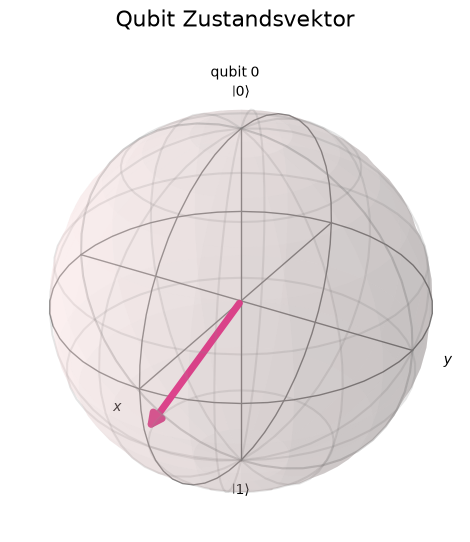

In [ ]:
plot_bloch_multivector(psi, "Qubit Zustandsvektor")

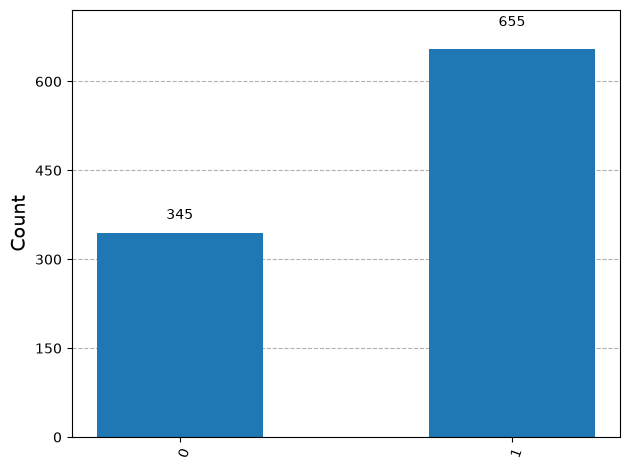

In [ ]:

statistics = psi.sample_counts(1000)
plot_histogram(statistics)

## Beispiele

Weitere Beispiele für gültige Qubit Zustandsvektoren sind die folgenden Vektoren:

In [ ]:

u = Statevector([sqrt(2)/2, sqrt(2)/2])
v = Statevector([(1/3 + 2/3j), -2 / 3])
w = Statevector([(-3/5), (4/5)])

print("Qubit_u =")
display(u.draw("text"))
display(u.draw("latex"))
print("\nQubit_v =")
display(v.draw("text"))
display(v.draw("latex"))
print("\nQubit_w =")
display(w.draw("text"))
display(w.draw("latex"))


Qubit_u =


[0.70710678+0.j,0.70710678+0.j]

<IPython.core.display.Latex object>


Qubit_v =


[ 0.33333333-0.66666667j,-0.66666667+0.j        ]

<IPython.core.display.Latex object>


Qubit_w =


[-0.6+0.j, 0.8+0.j]

<IPython.core.display.Latex object>

In [ ]:

print("Qubit_u gültig: ")
display(w.is_valid())
print("\nQubit_v gültig: ")
display(v.is_valid())
print("\nQubit_w gültig: ")
display(w.is_valid())

Qubit_u gültig: 


True


Qubit_v gültig: 


True


Qubit_w gültig: 


True

 Wenn das Qubit_u gemessen wird, ist das Ergebnis mit gleicher Wahrscheinlichkeit 0 und 1.

 D.h. der Erwartungswert für eine Messung in ⟨Z⟩ Richtung ist gleich 0.

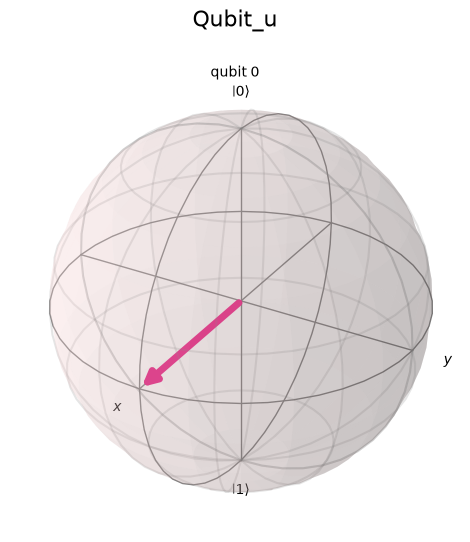

In [ ]:
plot_bloch_multivector(u,"Qubit_u")

In [ ]:
u_x = u.expectation_value(Pauli("X"))
print(f"Erwartungswert für X-Messung: {u_x}")
u_y = u.expectation_value(Pauli("Y"))
print(f"Erwartungswert für Y-Messung: {u_y}")
u_z = u.expectation_value(Pauli("Z"))
print(f"Erwartungswert für Z-Messung: {u_z}")

outcome, state = u.measure()
print(f"Der gemessener Wert kann 0 oder 1 sein. \nBei der aktuellen Messung ist der Wert {outcome}")


Erwartungswert für X-Messung: 1.0000000000000002
Erwartungswert für Y-Messung: 0.0
Erwartungswert für Z-Messung: 0.0
Der gemessener Wert kann 0 oder 1 sein. 
Bei der aktuellen Messung ist der Wert 1


Ergebnis von 1000 Messungen:

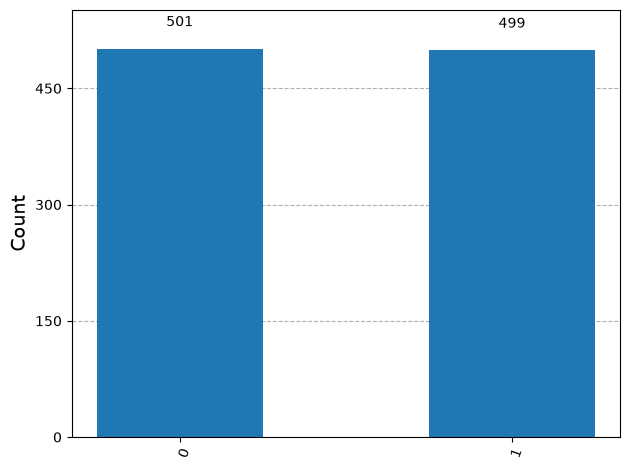

In [ ]:

statistics = u.sample_counts(1000)
plot_histogram(statistics)

Qubit_v enthält einen imaginären Anteil. Dadurch liegt der Pfeil nicht mehr in der x-z-Ebene. Er hat zusätzlich einen y Anteil.

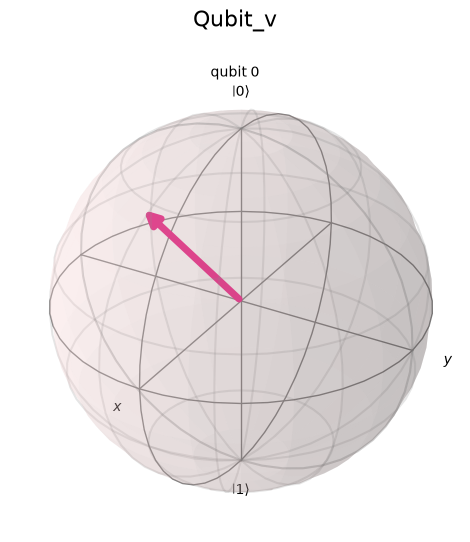

In [ ]:
plot_bloch_multivector(v, "Qubit_v")

In [ ]:
v_x = v.expectation_value(Pauli("X"))
print(f"Erwartungswert für X-Messung: {v_x}")
v_y = v.expectation_value(Pauli("Y"))
print(f"Erwartungswert für Y-Messung: {v_y}")
v_z = v.expectation_value(Pauli("Z"))
print(f"Erwartungswert für Z-Messung: {v_z}")



Erwartungswert für X-Messung: -0.4444444444444444
Erwartungswert für Y-Messung: -0.8888888888888888
Erwartungswert für Z-Messung: 0.11111111111111116


Der Erwartungswert für eine Z-Messung ist positiv, d.h. das Messergebnis 0 ist etwas wahrscheinlicher. Dies sieht man auch in dem Plot der 1000 Messungen visualisiert.

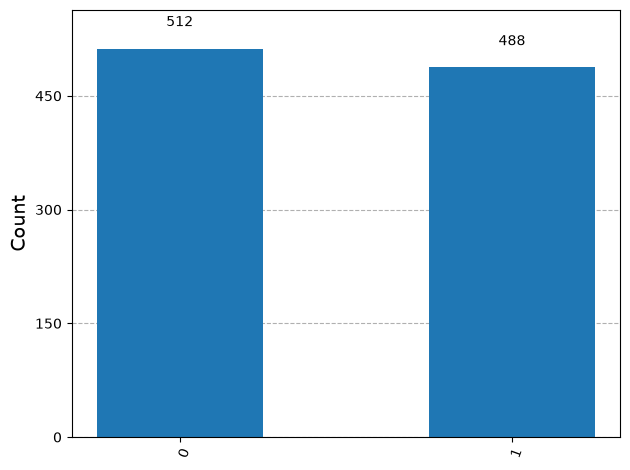

In [ ]:
statistics = v.sample_counts(1000)
plot_histogram(statistics)

Das Qubit_w liegt wieder in der x-z-Ebene. Bei diesem Qubit ist die Wahrscheinlichkeit von 1 größer als die Wahrscheinlichkeit für 0.

* Wahrscheinlichkeit 0: 9/25 = (-3/5) * (-3/5)
* Wahrscheinlichkeit 1: 16/25 = (4/5) * (4/5)

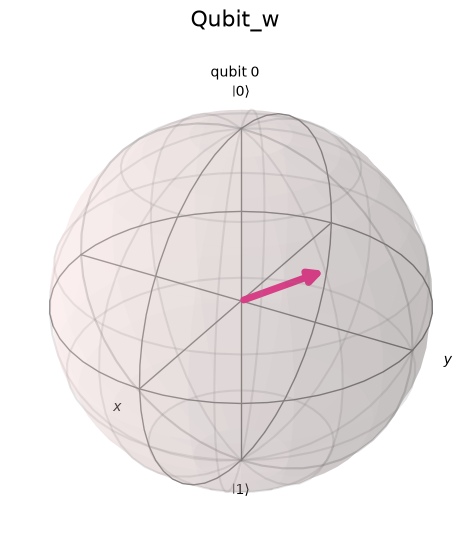

In [ ]:
plot_bloch_multivector(w, "Qubit_w")

In [ ]:
w_x = w.expectation_value(Pauli("X"))
print(f"Erwartungswert für X-Messung: {w_x}")
w_y = w.expectation_value(Pauli("Y"))
print(f"Erwartungswert für Y-Messung: {w_y}")
w_z = w.expectation_value(Pauli("Z"))
print(f"Erwartungswert für Z-Messung: {w_z}")

Erwartungswert für X-Messung: -0.96
Erwartungswert für Y-Messung: 0.0
Erwartungswert für Z-Messung: -0.28000000000000014


Ergebnis von 2500 Messungen:

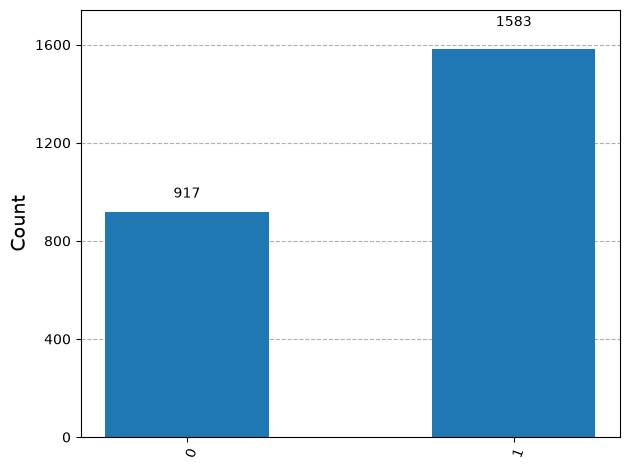

In [ ]:

statistics = w.sample_counts(2500)
plot_histogram(statistics)


<a id="gates"></a>
# Gates


Gates sind Bausteine (Quantengatter) die Qubitzustände verändern können und zu so genannten Circuits zusammengeschaltet werden.

Wichtige Beispiele für Gates die auf ein Qubit wirken sind:


* X-Gate: klassisches NOT
  (aus |0⟩ wird |1⟩)
* H-Gate (Hadamard): erzeugt eine Superposition (aus |1⟩ wird |-⟩ )
* Z-Gate: Veränderung der Phase (aus |-⟩ wird |+⟩)


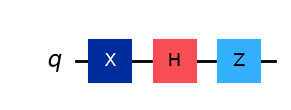

In [ ]:
qc = QuantumCircuit(1)
qc.x(0)
qc.h(0)
qc.z(0)
qc.draw(output='mpl')

Anfangszustand: 


<IPython.core.display.Latex object>


Zustand nach Gate  x


<IPython.core.display.Latex object>

Erwartungswert für X-Messung: 0.0
Erwartungswert für Y-Messung: 0.0
Erwartungswert für Z-Messung: -1.0


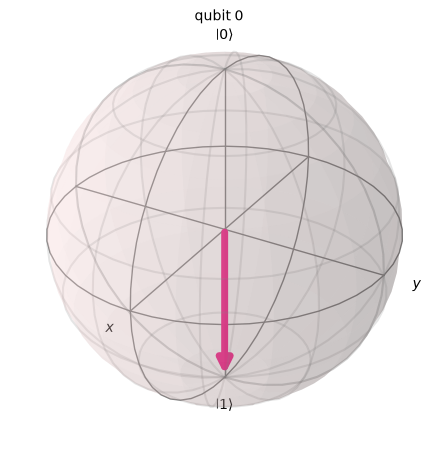


Zustand nach Gate  h


<IPython.core.display.Latex object>

Erwartungswert für X-Messung: -0.9999999999999998
Erwartungswert für Y-Messung: 0.0
Erwartungswert für Z-Messung: 0.0


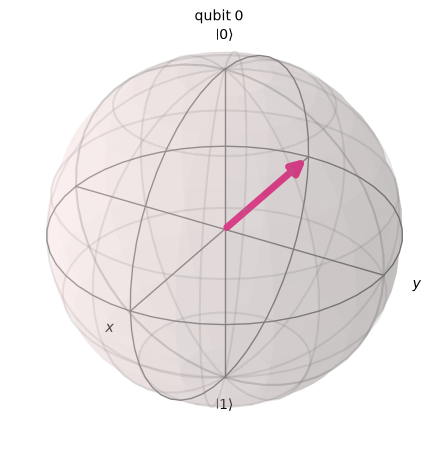


Zustand nach Gate  z


<IPython.core.display.Latex object>

Erwartungswert für X-Messung: 0.9999999999999998
Erwartungswert für Y-Messung: 0.0
Erwartungswert für Z-Messung: 0.0


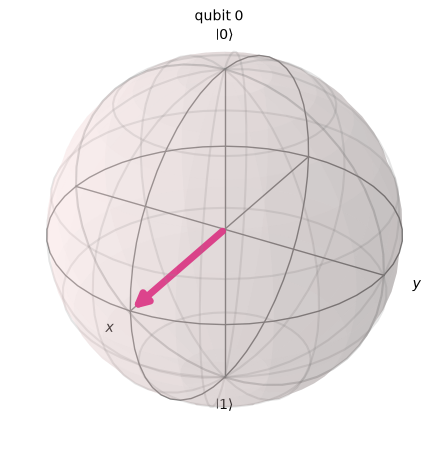

In [ ]:


#Anfangszustand
state = Statevector.from_label("0")

print("Anfangszustand: ")
display(state.draw("latex"))

for gate in qc.data:

  state = state.evolve(gate.operation)

  x = state.expectation_value(Pauli("X"))
  y = state.expectation_value(Pauli("Y"))
  z = state.expectation_value(Pauli("Z"))
  print("\nZustand nach Gate ", gate.operation.name)
  display(state.draw("latex"))
  print(f"Erwartungswert für X-Messung: {x}")
  print(f"Erwartungswert für Y-Messung: {y}")
  print(f"Erwartungswert für Z-Messung: {z}")

  fig = plot_bloch_multivector(state)
  display(fig)
  plt.close(fig)




Um zu sehen wie Gates auf Qubits wirken, kann der folgende Composer mit grafischer Oberfläche verwendet werden

https://quantum.cloud.ibm.com/composer

Ein wichtiges Beispiel ist das CNOT Gate, da es dazu verwendet werden kann, Qubits zu verschränken.

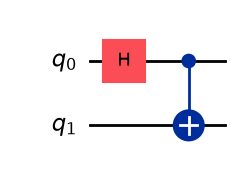

In [ ]:
qc2 = QuantumCircuit(2)
qc2.h(0)
qc2.cx(0,1)
qc2.draw(output='mpl')

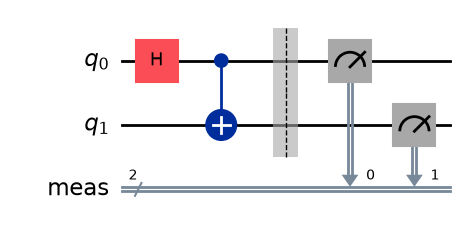

In [ ]:
qc2.measure_all()
qc2.draw(output='mpl')

Messergebnisse (Counts): {'00': 507, '11': 517}


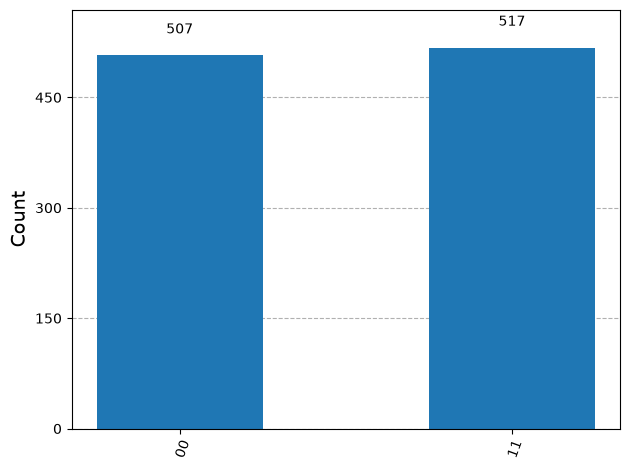

In [40]:


# Den Sampler initialisieren
sampler = StatevectorSampler()

# Den Job ausführen
pub = (qc2,)
job = sampler.run([pub])
result = job.result()

# Ergebnis der ersten (und einzigen) Ausführung abrufen
# 'get_counts()' die gemessenen Bitstrings und deren Häufigkeit
counts = result[0].data.meas.get_counts()

print("Messergebnisse (Counts):", counts)
plot_histogram(counts)


Man sieht, dass beide Qubits nach diesem Circuit den gleichen Wert haben und entweder beide 1 oder beide 0 sind.

<a id="observable"></a>
# Observable

In dem Beispiel zuvor wurde ein Sampler (Abtaster) verwendet. Der Circuit wurde ausgeführt und so wurde die Wahrscheinlichkeitsverteilung der Bitstrings (50% Chance für 11 und 50% für 00) ermittelt.

Eine andere Möglichkeit ist die Verwendung eines Estimators (Schätzers). Dieser benötigt einen Quantenschaltkreis (den Circuit) und ein Observable.

Damit berechnet er einen Erwartungswert und ist dadurch das Werkzeug, das für physikalische und chemische Simulationen verwendet wird.


Das Observable bestimmt was (welche Größe) gemessen werden soll.

Der Circuit bestimmt welcher Messwert/Erwartungswert ermittelt wird.


Observable Z heißt beispielsweise, dass der Circuit in Z-Richtung gemessen wird.

$$
Z =
\begin{pmatrix}
1 & 0\\
0 & -1
\end{pmatrix}
$$

Observable X heißt entsprechend: Circuit wird in X-Richtung gemessen.


$$
X =
\begin{pmatrix}
0 & 1\\
1 & 0
\end{pmatrix}
$$

Das Observable Z führt zu den folgenden zwei unterschiedlichen Messergebnissen:

* +1, wenn der Qubitustand |0⟩ ist
* -1, wenn der Qubitzustand |1⟩ ist


Viele Messungen => Erwartungswert

Beispiel:
* 70% der Messungen +1
* 30% der Messungen -1

Erwartungswert des  Observables Z

⟨ Z ⟩  = 0.7(+1) + 0.3(-1) = 0.4




**Beispiel 1:**

Qubit im Zustand
|0⟩,

Ergebnis der Z-Messung
+1.

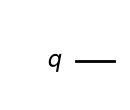

1.0


In [42]:
qc = QuantumCircuit(1)

display(qc.draw("mpl"))

observable = SparsePauliOp.from_list([("Z",1.0)])

estimator = StatevectorEstimator()

job = estimator.run([(qc,observable)])
result = job.result()[0]
print(result.data.evs)



**Beispiel 2:**

Qubit im Zustand
|1⟩,

Ergebnis der Z-Messung
-1.

In [ ]:
qc = QuantumCircuit(1)
qc.x(0)

observable = SparsePauliOp.from_list([("Z",1.0)])

estimator = StatevectorEstimator()

job = estimator.run([(qc,observable)])
result = job.result()[0]
print(result.data.evs)



-1.0


**Beispiel 3:**

Qubit im Zustand
|+⟩,

Erwartungswert ⟨Z⟩ = 0.

In [ ]:
qc = QuantumCircuit(1)
qc.h(0)

observable = SparsePauliOp.from_list([("Z",1.0)])

estimator = StatevectorEstimator()

job = estimator.run([(qc,observable)])
result = job.result()[0]
print(result.data.evs)



0.0


**Beispiel 4:**

Qubit im Zustand
|+⟩,

Erwartungswert ⟨X⟩ = +1.

In [ ]:
qc = QuantumCircuit(1)
qc.h(0)

observable = SparsePauliOp.from_list([("X",1.0)])

estimator = StatevectorEstimator()

job = estimator.run([(qc,observable)])
result = job.result()[0]
print(result.data.evs)

0.9999999999999998


**Beispiel 5:**

Qubit im Zustand
|-⟩,

Erwartungswert ⟨X⟩ = -1.

In [ ]:
qc = QuantumCircuit(1)
qc.x(0)
qc.h(0)

observable = SparsePauliOp.from_list([("X",1.0)])

estimator = StatevectorEstimator()

job = estimator.run([(qc,observable)])
result = job.result()[0]
print(result.data.evs)

-0.9999999999999998


**Beispiel 6:**

Beide Qubits im Zustand
|-⟩

da H · X |0⟩ = |-⟩

Der Gesamtzustand ist

|-⟩ ⊗ |-⟩ = |--⟩

Kombinierter Eigenwert

(-1) × (-1) = 1.0

0.9999999999999996


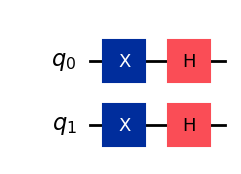

In [ ]:
qc = QuantumCircuit(2)
qc.x(0)
qc.h(0)
qc.x(1)
qc.h(1)

observable = SparsePauliOp.from_list([("XX",1.0)])

estimator = StatevectorEstimator()

job = estimator.run([(qc,observable)])
result = job.result()[0]

print(result.data.evs)

display(qc.draw("mpl"))



